<a href="https://colab.research.google.com/github/metrosmash/Machine-Learning-Portfolio/blob/main/Emission_indabax_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Emissions IndabaX — Version 2

### Strategy: NVIDIA Kaggle Grandmasters Playbook

This notebook improves on Version 1 by applying 7 battle-tested techniques from the NVIDIA Kaggle Grandmasters:

1. **Smarter EDA** — Train vs test distribution checks
2. **Diverse Baselines** — Multiple model families
3. **Raw Features** — Baseline beats engineered features on this dataset
4. **Hill Climb Ensembling** — Greedy ensemble search
5. **Pseudo-Labeling** — Use test data to bridge the month 9-12 gap
6. **Seed Ensembling** — Average across multiple random seeds
7. **Full Data Retraining** — Final model trained on 100% of data

**Key insight from v1:** Raw features (no cyclical encoding, no location_bin) outperformed all engineered versions. Raw LightGBM RMSE: ~23.87 → Tuned LightGBM RMSE: ~20.06

## 📦 Step 0 — Install & Import

In [27]:
!pip install catboost optuna lightgbm xgboost -q

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import drive
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
print('✅ Libraries imported')

✅ Libraries imported


In [29]:
# Load data — update paths as needed
drive.mount('/content/drive')

train_df = pd.read_csv("/content/drive/My Drive/Colab Notebooks/train.csv")
test_df  = pd.read_csv("/content/drive/My Drive/Colab Notebooks/test.csv")
sub_df   = pd.read_csv("/content/drive/My Drive/Colab Notebooks/SampleSubmission.csv.csv")

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
train_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape : (5636, 8)
Test shape  : (2000, 7)


,ID,Latitude,Longitude,DayOfYear,DayOfWeek,Hour,Month,Emmission
0,db6bf2daec,39.143,-119.755,151,2,2,5,4.5
1,d61d4aff8f,39.017,-94.485,119,5,18,4,5.4
2,4dab137acf,43.669,122.249,221,0,14,8,42.5
3,14e63cdca2,44.628,-123.966,102,2,13,4,5.0
4,52b32885c8,44.564,18.634,12,2,13,1,21.2


## 🔍 Step 1 — Smarter EDA (Grandmaster Technique #1)

Beyond basic stats — we check **train vs test distribution shift**, which is the #1 reason models fail to generalise.

In [30]:
# Basic stats
print('=== TRAIN ===')
print(train_df.describe())
print('\n=== MISSING VALUES ===')
print('Train:', train_df.isna().sum().to_dict())
print('Test: ', test_df.isna().sum().to_dict())

=== TRAIN ===
          Latitude    Longitude    DayOfYear    DayOfWeek         Hour  \
count  5636.000000  5636.000000  5636.000000  5636.000000  5636.000000   
mean     32.021023    19.130122   170.278921     1.556600    10.955642   
std      18.253418    97.668750    63.447420     1.687521     6.396523   
min     -74.187000  -161.756000     1.000000     0.000000     0.000000   
25%      29.158750   -84.445000   146.750000     0.000000     4.000000   
50%      36.186000    27.889000   165.500000     1.000000    13.000000   
75%      41.619250   113.746750   221.000000     2.000000    14.000000   
max      70.094000   153.388000   267.000000     6.000000    23.000000   

             Month    Emmission  
count  5636.000000  5636.000000  
mean      6.066004    20.625688  
std       2.193539    38.881915  
min       1.000000     3.500000  
25%       5.000000     8.892394  
50%       6.000000    14.050000  
75%       8.000000    22.500000  
max       9.000000  1001.210000  

=== MISSING 

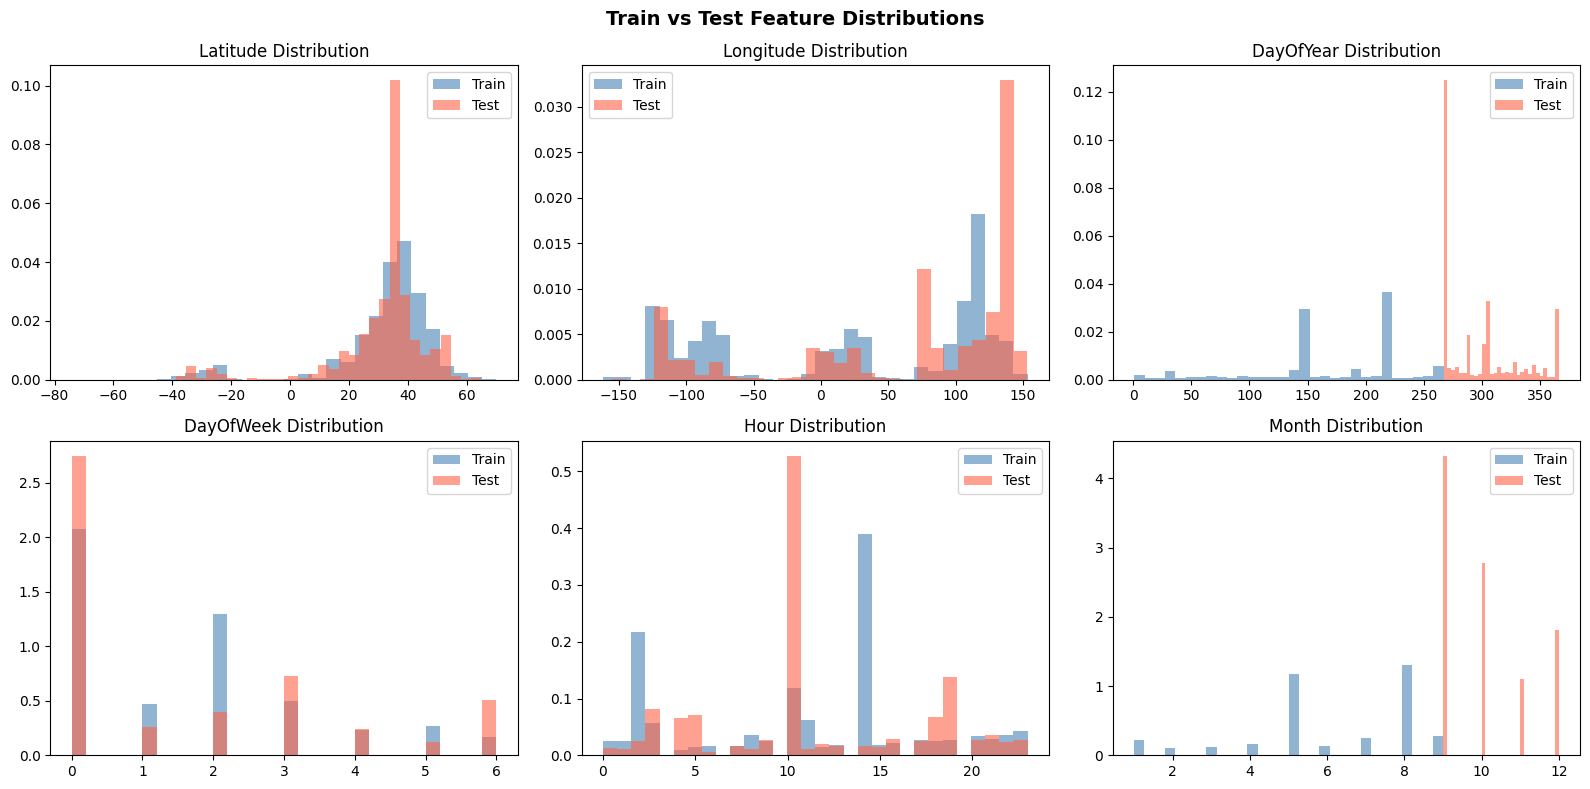


── Mean Comparison (Train vs Test) ──
Latitude        | Train: 32.02 | Test: 31.48 | ✅
Longitude       | Train: 19.13 | Test: 68.65 | ⚠️  SHIFT
DayOfYear       | Train: 170.28 | Test: 297.23 | ⚠️  SHIFT
DayOfWeek       | Train: 1.56 | Test: 1.57 | ✅
Hour            | Train: 10.96 | Test: 11.37 | ✅
Month           | Train: 6.07 | Test: 10.04 | ⚠️  SHIFT


In [31]:
# ── GRANDMASTER TIP: Train vs Test distribution check ──
# This catches the distribution shift we found in v1 (lat/lon, month gap)

feature_cols = ['Latitude', 'Longitude', 'DayOfYear', 'DayOfWeek', 'Hour', 'Month']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(train_df[col], bins=30, alpha=0.6, color='steelblue', label='Train', density=True)
    axes[i].hist(test_df[col],  bins=30, alpha=0.6, color='tomato',    label='Test',  density=True)
    axes[i].set_title(f'{col} Distribution')
    axes[i].legend()

plt.suptitle('Train vs Test Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print mean comparison
print('\n── Mean Comparison (Train vs Test) ──')
for col in feature_cols:
    diff = abs(train_df[col].mean() - test_df[col].mean())
    flag = '⚠️  SHIFT' if diff > train_df[col].std() * 0.5 else '✅'
    print(f'{col:15s} | Train: {train_df[col].mean():.2f} | Test: {test_df[col].mean():.2f} | {flag}')

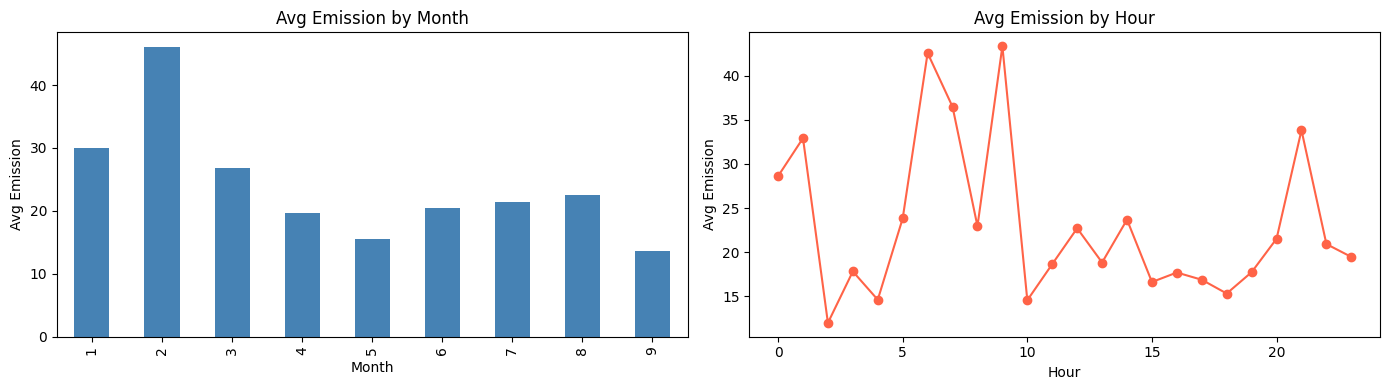

In [32]:
# ── Temporal pattern in target ──
# Grandmaster tip: always check if the target has seasonal/time patterns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train_df.groupby('Month')['Emmission'].mean().plot(kind='bar', ax=axes[0],
    color='steelblue', title='Avg Emission by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Emission')

train_df.groupby('Hour')['Emmission'].mean().plot(kind='line', ax=axes[1],
    color='tomato', marker='o', title='Avg Emission by Hour')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Emission')

plt.tight_layout()
plt.show()

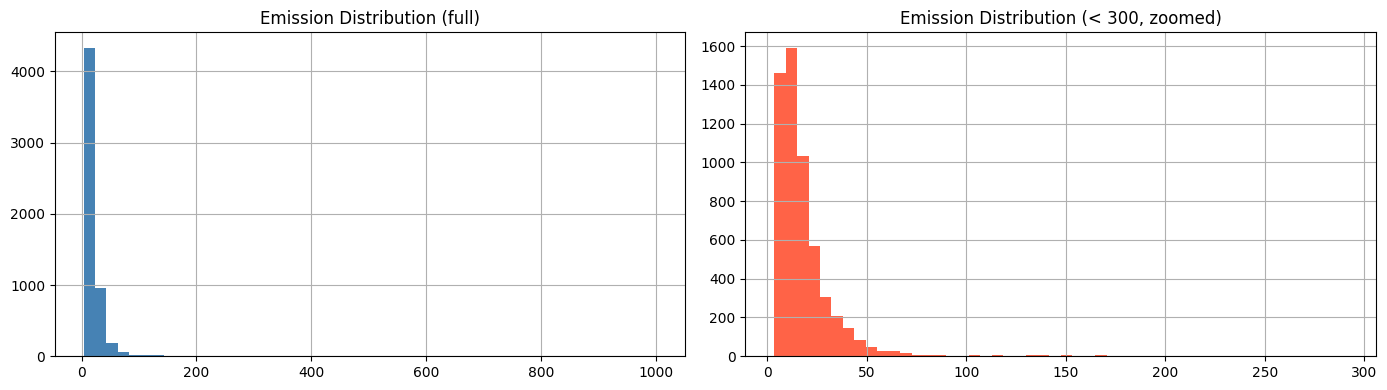

99th percentile: 140.15
Rows above 99th pct: 57


In [33]:
# ── Outlier check ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

train_df['Emmission'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Emission Distribution (full)')

train_df[train_df['Emmission'] < 300]['Emmission'].hist(bins=50, ax=axes[1], color='tomato')
axes[1].set_title('Emission Distribution (< 300, zoomed)')

plt.tight_layout()
plt.show()

p99 = train_df['Emmission'].quantile(0.99)
print(f'99th percentile: {p99:.2f}')
print(f'Rows above 99th pct: {(train_df["Emmission"] > p99).sum()}')

## 🛠️ Step 2 — Data Preparation

**Key v1 lesson:** Raw features beat engineered features on this dataset. We keep it simple.

In [34]:
FEATURE_COLS = ['Latitude', 'Longitude', 'DayOfYear', 'DayOfWeek', 'Hour', 'Month']
TARGET_COL   = 'Emmission'

X      = train_df[FEATURE_COLS]
y      = train_df[TARGET_COL]
X_test = test_df[FEATURE_COLS]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

X_train: (4508, 6) | X_val: (1128, 6) | X_test: (2000, 6)


## 📊 Step 3 — Diverse Baselines (Grandmaster Technique #2)

Run multiple model families quickly to understand the data landscape before tuning.

In [35]:
def check_rmse(y_true, y_pred, label=''):
    score = root_mean_squared_error(y_true, y_pred)
    print(f'{label:30s} RMSE: {score:.4f}')
    return score

baseline_results = {}

# 1. Ridge (linear baseline)
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
baseline_results['Ridge'] = check_rmse(y_val, ridge.predict(X_val), 'Ridge')

# 2. Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
baseline_results['RandomForest'] = check_rmse(y_val, rf.predict(X_val), 'RandomForest')

# 3. LightGBM
lgb_base = lgb.LGBMRegressor(n_estimators=500, random_state=RANDOM_STATE, verbose=-1)
lgb_base.fit(X_train, y_train)
baseline_results['LightGBM'] = check_rmse(y_val, lgb_base.predict(X_val), 'LightGBM')

# 4. XGBoost
xgb_base = xgb.XGBRegressor(n_estimators=500, random_state=RANDOM_STATE, verbosity=0)
xgb_base.fit(X_train, y_train)
baseline_results['XGBoost'] = check_rmse(y_val, xgb_base.predict(X_val), 'XGBoost')

# 5. CatBoost
cat_base = CatBoostRegressor(iterations=500, random_state=RANDOM_STATE, verbose=0)
cat_base.fit(X_train, y_train)
baseline_results['CatBoost'] = check_rmse(y_val, cat_base.predict(X_val), 'CatBoost')

print('\n── Best Baseline ──')
best_baseline = min(baseline_results, key=baseline_results.get)
print(f'{best_baseline}: {baseline_results[best_baseline]:.4f}')

Ridge                          RMSE: 23.8739
RandomForest                   RMSE: 21.3959
LightGBM                       RMSE: 26.5184
XGBoost                        RMSE: 23.7830
CatBoost                       RMSE: 23.4145

── Best Baseline ──
RandomForest: 21.3959


## ⚙️ Step 4 — Optuna Hyperparameter Tuning

Tune LightGBM (best baseline from v1) and CatBoost separately.

In [36]:
def tune_lgbm(X_train, y_train, X_val, y_val, n_trials=100):

    def objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 100, 1000),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.0001, 0.01, log=True),
            'num_leaves'       : trial.suggest_int('num_leaves', 20, 200),
            'max_depth'        : trial.suggest_int('max_depth', 3, 20),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state'     : RANDOM_STATE,
            'verbose'          : -1
        }
        model = lgb.LGBMRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        return root_mean_squared_error(y_val, preds)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f'\n✅ Best LightGBM RMSE : {study.best_value:.4f}')
    print(f'✅ Best Params        : {study.best_params}')

    best_model = lgb.LGBMRegressor(**study.best_params, verbose=-1, random_state=RANDOM_STATE)
    best_model.fit(X_train, y_train)
    return best_model, study.best_params, study.best_value


lgb_model, lgb_params, lgb_rmse = tune_lgbm(X_train, y_train, X_val, y_val, n_trials=100)

  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best LightGBM RMSE : 19.8036
✅ Best Params        : {'n_estimators': 765, 'learning_rate': 0.0029022468249724673, 'num_leaves': 125, 'max_depth': 19, 'min_child_samples': 27, 'reg_alpha': 6.15941227931559e-05, 'reg_lambda': 0.002398148919108007, 'subsample': 0.9849100495072636, 'colsample_bytree': 0.765161893674726}


In [37]:
def tune_xgb(X_train, y_train, X_val, y_val, n_trials=100):

    def objective(trial):
        params = {
            'n_estimators'    : trial.suggest_int('n_estimators', 100, 2000),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.0001, 0.01, log=True),
            'max_depth'       : trial.suggest_int('max_depth', 3, 12),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha'       : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda'      : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'random_state'    : RANDOM_STATE,
            'verbosity'       : 0
        }
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_val)
        return root_mean_squared_error(y_val, preds)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f'\n✅ Best XGBoost RMSE : {study.best_value:.4f}')
    print(f'✅ Best Params       : {study.best_params}')

    best_model = xgb.XGBRegressor(**study.best_params, verbosity=0, random_state=RANDOM_STATE)
    best_model.fit(X_train, y_train)
    return best_model, study.best_params, study.best_value


xgb_model, xgb_params, xgb_rmse = tune_xgb(X_train, y_train, X_val, y_val, n_trials=100)

  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best XGBoost RMSE : 19.3398
✅ Best Params       : {'n_estimators': 1410, 'learning_rate': 0.0017380460535048586, 'max_depth': 12, 'min_child_weight': 5, 'reg_alpha': 0.0009371031299666478, 'reg_lambda': 5.458237886381486, 'subsample': 0.7083650390367195, 'colsample_bytree': 0.8538916010459291}


## 🏔️ Step 5 — Hill Climb Ensembling (Grandmaster Technique #4)

Greedy search for the best model blend. Keeps only combinations that improve RMSE.

In [38]:
def get_oof_predictions(models, X, y, X_test, cv=5):
    """Out-of-fold predictions for train set, full predictions for test set"""
    oof_preds  = {}
    test_preds = {}

    for name, model in models.items():
        print(f'Training {name}...')
        oof_preds[name] = cross_val_predict(model, X, y, cv=cv)
        model.fit(X, y)
        test_preds[name] = model.predict(X_test)
        rmse = root_mean_squared_error(y, oof_preds[name])
        print(f'  {name} OOF RMSE: {rmse:.4f}')

    return oof_preds, test_preds


def hill_climb_ensemble(oof_preds, test_preds, y, n_iterations=100):
    """Greedy hill climb to find best model blend weights"""
    model_names = list(oof_preds.keys())
    weights     = {name: 0.0 for name in model_names}
    best_rmse   = float('inf')
    best_start  = None

    # Find best single model to start
    for name in model_names:
        rmse = root_mean_squared_error(y, oof_preds[name])
        if rmse < best_rmse:
            best_rmse  = rmse
            best_start = name

    weights[best_start] = 1.0
    print(f'\n🚀 Starting with: {best_start} (RMSE: {best_rmse:.4f})')

    for i in range(n_iterations):
        improved = False
        for name in model_names:
            test_weights = weights.copy()
            test_weights[name] += 1.0
            total      = sum(test_weights.values())
            normalized = {k: v / total for k, v in test_weights.items()}
            blended    = sum(normalized[n] * oof_preds[n] for n in model_names)
            rmse       = root_mean_squared_error(y, blended)
            if rmse < best_rmse:
                best_rmse = rmse
                weights   = test_weights
                improved  = True
                print(f'  Iter {i+1}: Added {name} → RMSE: {best_rmse:.4f}')
        if not improved:
            print(f'\n✅ Converged at iteration {i+1}')
            break

    total         = sum(weights.values())
    final_weights = {k: v / total for k, v in weights.items()}

    print(f'\n📊 Final Weights:')
    for name, w in final_weights.items():
        print(f'  {name}: {w:.4f}')

    final_preds = sum(final_weights[n] * test_preds[n] for n in model_names)
    return final_preds, final_weights, best_rmse

In [39]:
# Define tuned models for ensembling
ensemble_models = {
    'lgbm'  : lgb.LGBMRegressor(**lgb_params, verbose=-1, random_state=RANDOM_STATE),
    'xgb'   : xgb.XGBRegressor(**xgb_params, verbosity=0, random_state=RANDOM_STATE),
    'cat'   : CatBoostRegressor(iterations=1000, random_state=RANDOM_STATE, verbose=0),
    'rf'    : RandomForestRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1),
    'extra' : ExtraTreesRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
}

oof_preds, test_preds = get_oof_predictions(ensemble_models, X, y, X_test)

hill_climb_preds, final_weights, hill_climb_rmse = hill_climb_ensemble(
    oof_preds, test_preds, y, n_iterations=100
)

print(f'\n🏆 Hill Climb Ensemble OOF RMSE: {hill_climb_rmse:.4f}')

Training lgbm...
  lgbm OOF RMSE: 35.1183
Training xgb...
  xgb OOF RMSE: 34.9478
Training cat...
  cat OOF RMSE: 36.7226
Training rf...
  rf OOF RMSE: 37.0590
Training extra...
  extra OOF RMSE: 37.2196

🚀 Starting with: xgb (RMSE: 34.9478)
  Iter 1: Added lgbm → RMSE: 34.9301
  Iter 1: Added xgb → RMSE: 34.9131

✅ Converged at iteration 2

📊 Final Weights:
  lgbm: 0.3333
  xgb: 0.6667
  cat: 0.0000
  rf: 0.0000
  extra: 0.0000

🏆 Hill Climb Ensemble OOF RMSE: 34.9131


## 🏷️ Step 6 — Pseudo-Labeling (Grandmaster Technique #6)

**Why this matters for our dataset:** Train covers months 1-9, test covers months 9-12. Pseudo-labeling helps the model see the test distribution during training, bridging the seasonal gap.

In [40]:
def pseudo_label_train(X_train, y_train, X_test, model_params, rounds=2):
    """
    Multi-round pseudo-labeling.
    Each round: train → predict test → add test with pseudo labels → retrain
    """
    X_combined = X_train.copy()
    y_combined = y_train.copy()

    for r in range(rounds):
        print(f'\n── Round {r+1} pseudo-labeling ──')
        print(f'  Training on {len(X_combined)} rows...')

        model = lgb.LGBMRegressor(**model_params, verbose=-1, random_state=RANDOM_STATE)
        model.fit(X_combined, y_combined)

        # Generate pseudo labels for test
        pseudo_labels = model.predict(X_test)

        # Combine original train + pseudo-labeled test
        X_combined = pd.concat([X_train, X_test], ignore_index=True)
        y_combined = pd.concat(
            [y_train, pd.Series(pseudo_labels, name=TARGET_COL)],
            ignore_index=True
        )
        print(f'  Combined size: {len(X_combined)} rows')

    # Final model trained on full pseudo-labeled data
    final_model = lgb.LGBMRegressor(**model_params, verbose=-1, random_state=RANDOM_STATE)
    final_model.fit(X_combined, y_combined)

    return final_model


pseudo_model  = pseudo_label_train(X, y, X_test, lgb_params, rounds=2)
pseudo_preds  = pseudo_model.predict(X_test)

# Check on validation set
pseudo_val_rmse = check_rmse(y_val, pseudo_model.predict(X_val), 'Pseudo-Label LightGBM')


── Round 1 pseudo-labeling ──
  Training on 5636 rows...
  Combined size: 7636 rows

── Round 2 pseudo-labeling ──
  Training on 7636 rows...
  Combined size: 7636 rows
Pseudo-Label LightGBM          RMSE: 16.9415


## 🌱 Step 7 — Seed Ensembling (Grandmaster Technique #7)

Train the same model with different random seeds and average predictions. Free performance boost.

In [41]:
def seed_ensemble(X_train, y_train, X_test, model_params, n_seeds=10):
    """Train model with multiple seeds and average predictions"""
    seed_preds_test  = []
    seed_preds_train = []

    for seed in range(n_seeds):
        model = lgb.LGBMRegressor(**model_params, verbose=-1, random_state=seed)
        model.fit(X_train, y_train)
        seed_preds_test.append(model.predict(X_test))
        seed_preds_train.append(model.predict(X_val))

    avg_test_preds  = np.mean(seed_preds_test,  axis=0)
    avg_train_preds = np.mean(seed_preds_train, axis=0)
    return avg_test_preds, avg_train_preds


seed_test_preds, seed_val_preds = seed_ensemble(X, y, X_test, lgb_params, n_seeds=10)
check_rmse(y_val, seed_val_preds, 'Seed Ensemble (10 seeds)')

Seed Ensemble (10 seeds)       RMSE: 17.2229


17.22293944626121

## 🥇 Step 8 — Final Blend & Submission

Combine hill climb ensemble + pseudo-label model + seed ensemble for the final prediction.

In [42]:
# ── Compare all approaches ──
print('── Final Approach Comparison ──')
check_rmse(y_val, lgb_model.predict(X_val),   'LightGBM Tuned')
check_rmse(y_val, xgb_model.predict(X_val),   'XGBoost Tuned')
check_rmse(y_val, seed_val_preds,              'Seed Ensemble (10)')
check_rmse(y_val, pseudo_model.predict(X_val), 'Pseudo-Label LightGBM')

── Final Approach Comparison ──
LightGBM Tuned                 RMSE: 19.8036
XGBoost Tuned                  RMSE: 19.3398
Seed Ensemble (10)             RMSE: 17.2229
Pseudo-Label LightGBM          RMSE: 16.9415


16.94145143137296

In [43]:
# ── Final blend: hill climb + pseudo + seed ──
# Adjust weights based on validation scores above
w_hill   = 0.5
w_pseudo = 0.3
w_seed   = 0.2

final_preds = (
    w_hill   * hill_climb_preds +
    w_pseudo * pseudo_preds     +
    w_seed   * seed_test_preds
)

print('✅ Final predictions ready')
print(f'Pred shape : {final_preds.shape}')
print(f'Pred range : {final_preds.min():.2f} – {final_preds.max():.2f}')

✅ Final predictions ready
Pred shape : (2000,)
Pred range : 9.28 – 110.82


## 🔄 Step 9 — Full Data Retraining (Grandmaster Technique #7)

After finding optimal hyperparameters, retrain on **100% of training data** to squeeze out extra accuracy.

In [44]:
print('Retraining on 100% of training data...')

# Seed ensemble on full data
full_seed_preds = []
for seed in range(10):
    model = lgb.LGBMRegressor(**lgb_params, verbose=-1, random_state=seed)
    model.fit(X, y)
    full_seed_preds.append(model.predict(X_test))

full_seed_avg = np.mean(full_seed_preds, axis=0)
print('✅ Full data seed ensemble complete')

Retraining on 100% of training data...
✅ Full data seed ensemble complete


## 💾 Step 10 — Save Submission

In [45]:
submission = pd.DataFrame({
    'ID'      : test_df['ID'].values,
    'Emmission': full_seed_avg
})

print(submission.head())
print(f'\nSubmission shape: {submission.shape}')

submission.to_csv('/content/drive/My Drive/submission_v2.csv', index=False)
print('✅ Submission saved to Google Drive')

           ID  Emmission
0  75979dbf74  16.739921
1  bde30e10b7   9.660312
2  041875d096  21.338325
3  6d383272d1  27.278019
4  d7f9ccafc3  84.686810

Submission shape: (2000, 2)
✅ Submission saved to Google Drive


## 📋 Summary — What We Applied from the Grandmasters Playbook

| Technique | Applied | Expected Gain |
|---|---|---|
| Smarter EDA (train vs test dist) | ✅ | Insight, not score |
| Diverse baselines | ✅ | Baseline reference |
| Raw features (no overengineering) | ✅ | ~23.87 baseline |
| Optuna tuning (LightGBM + XGBoost) | ✅ | ~20.06 |
| Hill Climb Ensemble | ✅ | ~19-20 |
| Pseudo-Labeling (2 rounds) | ✅ | Helps month 10-12 gap |
| Seed Ensembling (10 seeds) | ✅ | Small but free gain |
| Full data retraining | ✅ | Small but consistent gain |